# LaLiga Teams Logo Classification with CNN / EfficientNet — Fixed

This version fixes the dataset path error.

Your Kaggle dataset already has this structure:

```text
DATA_DIR/
    train/
        class folders...
    val/
        class folders...
    test/
        class folders...
```

So the notebook must **not** search for classes directly inside `DATA_DIR`.

Correct logic:

```text
classes = folders inside DATA_DIR/train
```

Then preprocessing keeps the same original split:

```text
original train -> processed train
original val   -> processed val
original test  -> processed test
```


## 1. Import Libraries

In [1]:
import os
import cv2
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

2026-05-30 21:39:59.343070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780177199.567658      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780177199.631477      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780177200.162937      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780177200.162981      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780177200.162984      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


## 2. Settings and Paths

In [2]:
INPUT_ROOT = "/kaggle/input"
WORKING_ROOT = "/kaggle/working"

PREPROCESSED_ROOT = os.path.join(WORKING_ROOT, "laliga_preprocessed")

TRAIN_DIR = os.path.join(PREPROCESSED_ROOT, "train")
VAL_DIR = os.path.join(PREPROCESSED_ROOT, "val")
TEST_DIR = os.path.join(PREPROCESSED_ROOT, "test")

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

image_exts = (".jpg", ".jpeg", ".png", ".webp", ".bmp", ".gif")

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 3. Detect Dataset Directory Automatically

Kaggle datasets sometimes have one extra folder inside `/kaggle/input/`.  
This cell searches for the real folder that contains the class folders.

In [3]:
def find_split_dataset_root(root):
    print("Searching inside:", root)

    possible_roots = []

    for dirpath, dirnames, filenames in os.walk(root):
        dirnames_lower = [d.lower() for d in dirnames]

        if "train" in dirnames_lower and "val" in dirnames_lower and "test" in dirnames_lower:
            possible_roots.append(dirpath)

    if len(possible_roots) == 0:
        print("No train/val/test dataset root found.")
        print()
        print("Folders available in /kaggle/input:")
        print(os.listdir(root))

        raise FileNotFoundError(
            "Could not find a dataset folder containing train, val, and test. "
            "Make sure the dataset is attached to the notebook."
        )

    # Usually the deepest matching path is the correct one
    possible_roots = sorted(possible_roots, key=lambda x: len(x), reverse=True)

    return possible_roots[0]


DATA_DIR = find_split_dataset_root(INPUT_ROOT)

print("Detected dataset directory:")
print(DATA_DIR)

ORIGINAL_TRAIN_DIR = os.path.join(DATA_DIR, "train")
ORIGINAL_VAL_DIR   = os.path.join(DATA_DIR, "val")
ORIGINAL_TEST_DIR  = os.path.join(DATA_DIR, "test")

print("Original train:", ORIGINAL_TRAIN_DIR)
print("Original val:", ORIGINAL_VAL_DIR)
print("Original test:", ORIGINAL_TEST_DIR)

Searching inside: /kaggle/input
Detected dataset directory:
/kaggle/input/datasets/tomasawad/laliga-teams-logo/Laliga teams logo
Original train: /kaggle/input/datasets/tomasawad/laliga-teams-logo/Laliga teams logo/train
Original val: /kaggle/input/datasets/tomasawad/laliga-teams-logo/Laliga teams logo/val
Original test: /kaggle/input/datasets/tomasawad/laliga-teams-logo/Laliga teams logo/test


## 4. Check Classes and Image Counts

In [4]:
classes = sorted([
    d for d in os.listdir(ORIGINAL_TRAIN_DIR)
    if os.path.isdir(os.path.join(ORIGINAL_TRAIN_DIR, d))
])

print("Number of classes:", len(classes))
print("Classes:")
print(classes)

if len(classes) == 0:
    raise RuntimeError("No class folders found inside the train folder.")

Number of classes: 40
Classes:
['Albacete', 'Almeria', 'Andorra', 'Athletic Bilbao', 'Atletico Madrid', 'Barcelona', 'Burgos', 'Cadiz', 'Castellon', 'Celta Vigo', 'Ceuta', 'Cultural y Deportiva Leonesa', 'Deportivo Alaves', 'Deportivo de La Coruna', 'Eibar', 'Elche', 'Espanyol', 'Getafe', 'Girona', 'Granada', 'Huesca', 'Las Palmas', 'Leganes', 'Levante', 'Malaga', 'Mallorca', 'Mirandes', 'Osasuna', 'Rayo Vallecano', 'Real Betis', 'Real Madrid', 'Real Oviedo', 'Real Racing', 'Real Sociedad', 'Real Valladolid', 'Real Zaragoza', 'Sevilla', 'Sporting Gijon', 'Valencia', 'Villarreal']


##%% md
## 5. Count Images in Train / Val / Test

In [5]:
def count_images_per_split(split_dir, classes):
    counts = {}

    for cls in classes:
        cls_path = os.path.join(split_dir, cls)

        if not os.path.exists(cls_path):
            counts[cls] = 0
            continue

        images = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(image_exts)
        ]

        counts[cls] = len(images)

    return counts


train_counts = count_images_per_split(ORIGINAL_TRAIN_DIR, classes)
val_counts = count_images_per_split(ORIGINAL_VAL_DIR, classes)
test_counts = count_images_per_split(ORIGINAL_TEST_DIR, classes)

df_counts = pd.DataFrame({
    "class": classes,
    "train": [train_counts[c] for c in classes],
    "val": [val_counts[c] for c in classes],
    "test": [test_counts[c] for c in classes],
})

df_counts["total"] = df_counts["train"] + df_counts["val"] + df_counts["test"]

df_counts

,class,train,val,test,total
0,Albacete,1040,130,130,1300
1,Almeria,1040,129,131,1300
2,Andorra,1040,130,130,1300
3,Athletic Bilbao,1040,130,130,1300
4,Atletico Madrid,1040,130,130,1300
5,Barcelona,1040,130,130,1300
6,Burgos,1039,129,131,1299
7,Cadiz,1040,130,130,1300
8,Castellon,1039,129,131,1299
9,Celta Vigo,1040,130,130,1300


## 6. Visualize Class Distribution

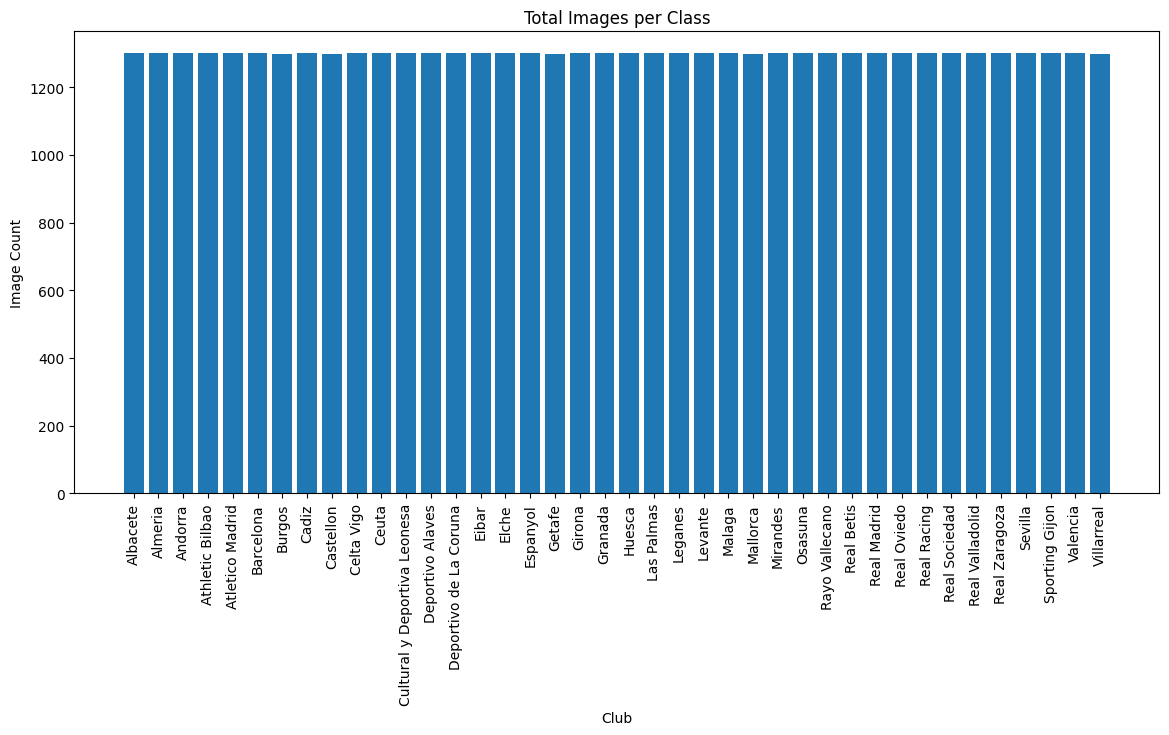

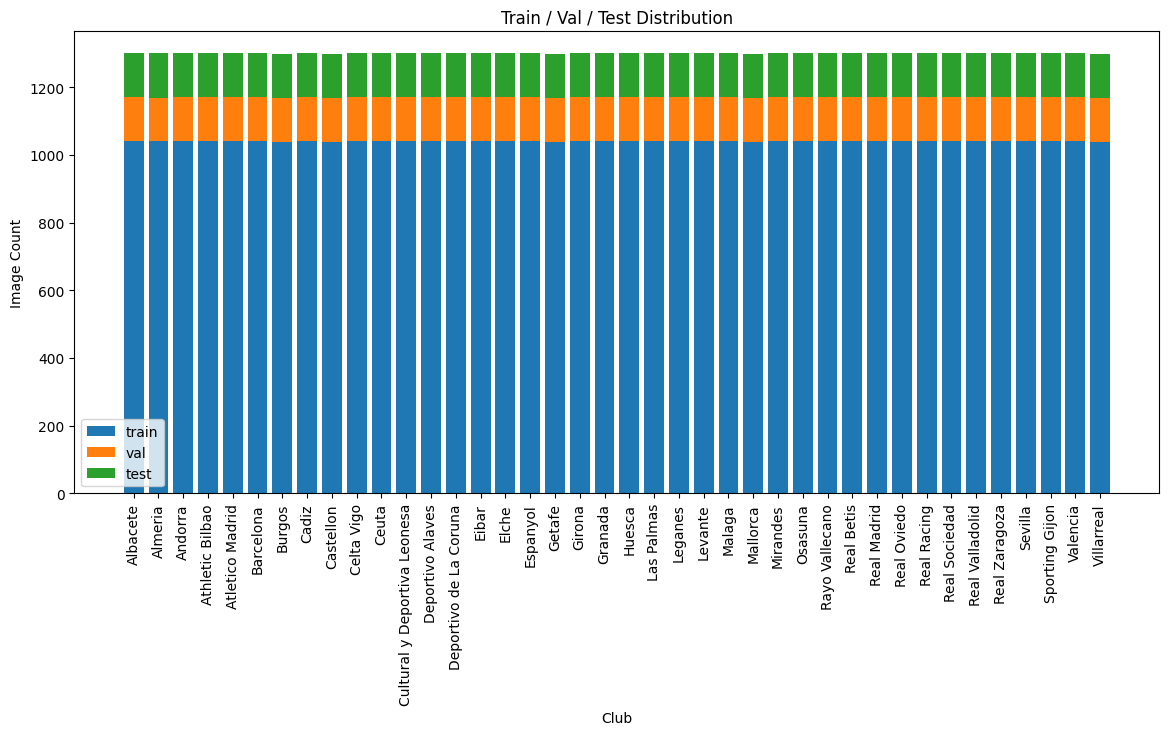

In [6]:
plt.figure(figsize=(14, 6))
plt.bar(df_counts["class"], df_counts["total"])
plt.xticks(rotation=90)
plt.title("Total Images per Class")
plt.xlabel("Club")
plt.ylabel("Image Count")
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(df_counts["class"], df_counts["train"], label="train")
plt.bar(df_counts["class"], df_counts["val"], bottom=df_counts["train"], label="val")
plt.bar(df_counts["class"], df_counts["test"], bottom=df_counts["train"] + df_counts["val"], label="test")
plt.xticks(rotation=90)
plt.title("Train / Val / Test Distribution")
plt.xlabel("Club")
plt.ylabel("Image Count")
plt.legend()
plt.show()

## 7. Show Random Original Images

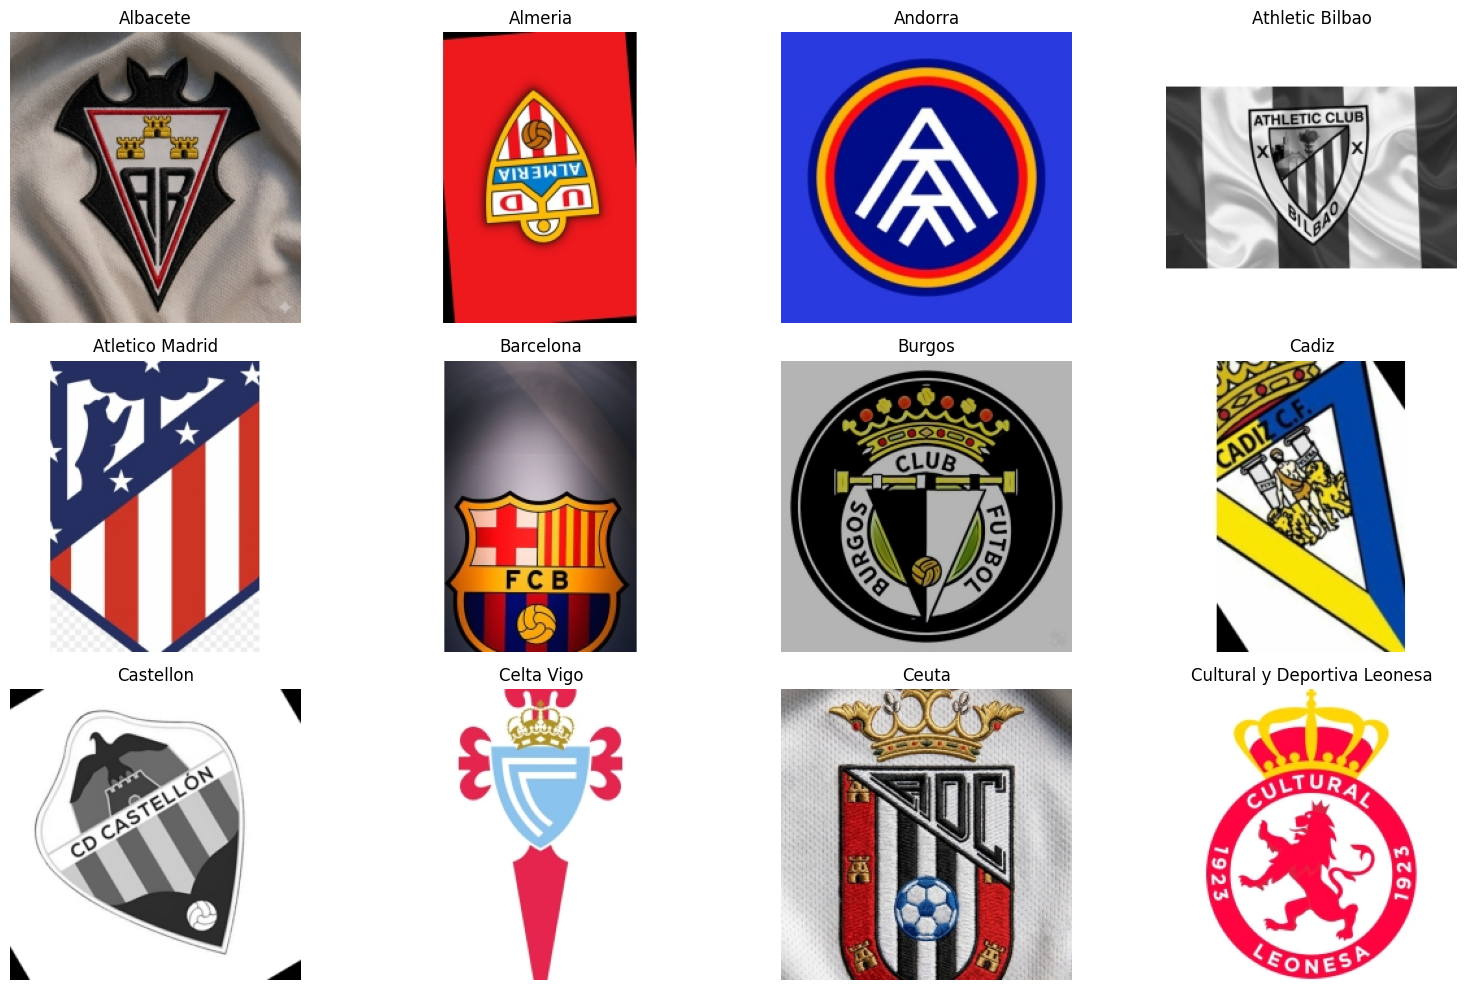

In [7]:
sample_images = []

for cls in classes:
    cls_path = os.path.join(ORIGINAL_TRAIN_DIR, cls)

    imgs = [
        os.path.join(cls_path, f)
        for f in os.listdir(cls_path)
        if f.lower().endswith(image_exts)
    ]

    if len(imgs) > 0:
        sample_images.append(random.choice(imgs))

sample_images = sample_images[:12]

plt.figure(figsize=(16, 10))

for i, img_path in enumerate(sample_images):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

    if img is None:
        continue

    if len(img.shape) == 2:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:
        img_rgb = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2RGB)
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img_rgb)
    plt.title(Path(img_path).parent.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Preprocessing Strategy

This dataset should not be trained directly without inspection, because CNNs can easily learn background noise.

The preprocessing below tries to isolate the logo without needing a manually labeled segmentation mask.

This is not a full U-Net segmentation model.  
It is a practical **logo extraction preprocessing** step.

## 7. Background Removal / Logo Isolation Function

In [8]:
def preprocess_logo_image(image_path, output_size=224, use_grabcut=True):
    """
    Better preprocessing for this dataset.

    It does:
    - Read image
    - Try GrabCut foreground extraction
    - If GrabCut fails, use original image
    - Resize with padding
    """

    img = cv2.imread(image_path, cv2.IMREAD_COLOR)

    if img is None:
        return None

    h, w = img.shape[:2]

    # Convert BGR to RGB
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if use_grabcut:
        try:
            mask = np.zeros((h, w), np.uint8)

            bgd_model = np.zeros((1, 65), np.float64)
            fgd_model = np.zeros((1, 65), np.float64)

            # Rectangle assumes logo/object is mostly inside the image center
            margin_x = int(w * 0.05)
            margin_y = int(h * 0.05)

            rect = (
                margin_x,
                margin_y,
                w - 2 * margin_x,
                h - 2 * margin_y
            )

            cv2.grabCut(
                img,
                mask,
                rect,
                bgd_model,
                fgd_model,
                5,
                cv2.GC_INIT_WITH_RECT
            )

            mask2 = np.where(
                (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
                1,
                0
            ).astype("uint8")

            # If mask is too small or too large, ignore GrabCut
            foreground_ratio = mask2.mean()

            if foreground_ratio > 0.05 and foreground_ratio < 0.95:
                white_bg = np.ones_like(rgb) * 255
                rgb = rgb * mask2[:, :, np.newaxis] + white_bg * (1 - mask2[:, :, np.newaxis])
                rgb = rgb.astype(np.uint8)

        except Exception:
            pass

    # Resize with padding, not stretching
    old_h, old_w = rgb.shape[:2]

    scale = output_size / max(old_h, old_w)

    new_w = int(old_w * scale)
    new_h = int(old_h * scale)

    resized = cv2.resize(rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

    final_img = np.ones((output_size, output_size, 3), dtype=np.uint8) * 255

    y_offset = (output_size - new_h) // 2
    x_offset = (output_size - new_w) // 2

    final_img[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized

    return final_img

## 8. Preview Preprocessing Results

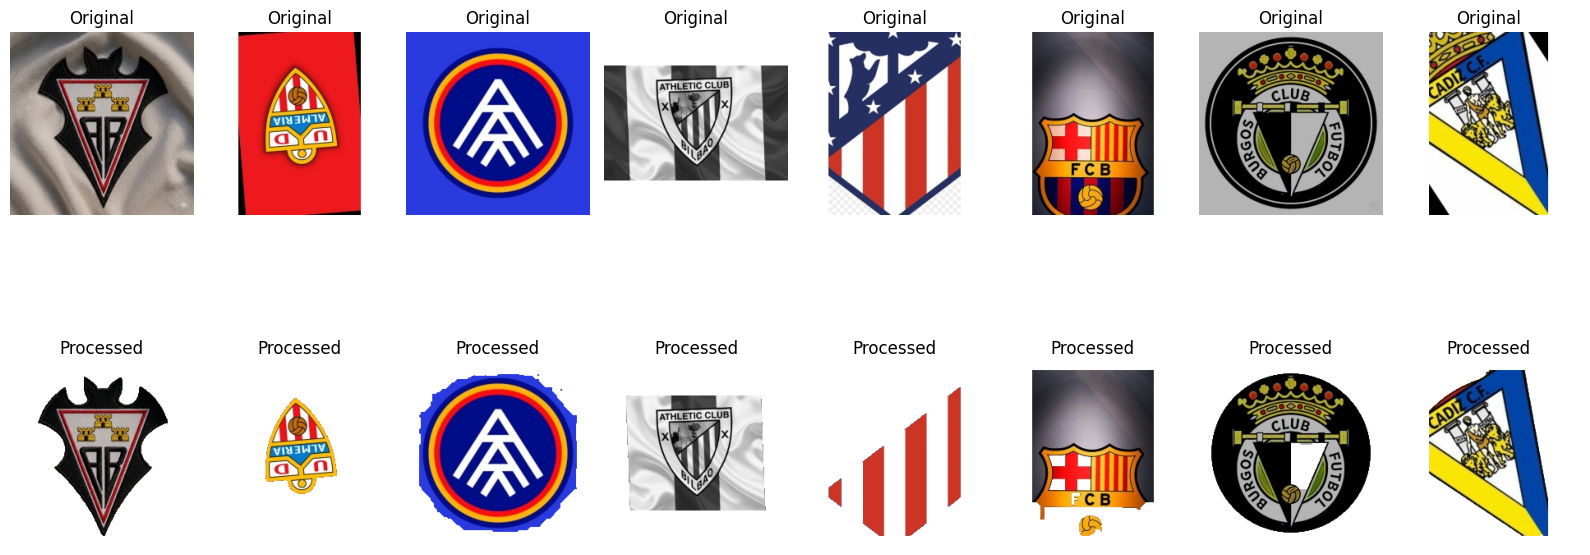

In [9]:
preview_images = sample_images[:8]

plt.figure(figsize=(16, 8))

for i, img_path in enumerate(preview_images):
    original = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

    if original is None:
        continue

    if len(original.shape) == 2:
        original_rgb = cv2.cvtColor(original, cv2.COLOR_GRAY2RGB)
    elif original.shape[2] == 4:
        original_rgb = cv2.cvtColor(original[:, :, :3], cv2.COLOR_BGR2RGB)
    else:
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    processed = preprocess_logo_image(
    img_path,
    output_size=IMG_SIZE,
    use_grabcut=True
    )

    plt.subplot(2, len(preview_images), i + 1)
    plt.imshow(original_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, len(preview_images), i + 1 + len(preview_images))
    plt.imshow(processed)
    plt.title("Processed")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Create Preprocessed Dataset while Keeping Train / Val / Test Split

The dataset already contains `train`, `val`, and `test`, so we keep the same split.

This fixes the error:

```text
FileNotFoundError: DATA_DIR/Albacete
```

because classes are not directly inside `DATA_DIR`; they are inside `DATA_DIR/train`, `DATA_DIR/val`, and `DATA_DIR/test`.


In [10]:
if os.path.exists(PREPROCESSED_ROOT):
    shutil.rmtree(PREPROCESSED_ROOT)

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

split_map = {
    "train": (ORIGINAL_TRAIN_DIR, TRAIN_DIR),
    "val": (ORIGINAL_VAL_DIR, VAL_DIR),
    "test": (ORIGINAL_TEST_DIR, TEST_DIR),
}

bad_images = []

for split_name, (input_split_dir, output_split_dir) in split_map.items():
    print(f"Processing split: {split_name}")

    for cls in tqdm(classes, desc=f"Preprocessing {split_name}"):
        input_cls_dir = os.path.join(input_split_dir, cls)
        output_cls_dir = os.path.join(output_split_dir, cls)

        os.makedirs(output_cls_dir, exist_ok=True)

        if not os.path.exists(input_cls_dir):
            print(f"Missing class folder in {split_name}: {input_cls_dir}")
            continue

        images = [
            f for f in os.listdir(input_cls_dir)
            if f.lower().endswith(image_exts)
        ]

        for idx, img_name in enumerate(images):
            img_path = os.path.join(input_cls_dir, img_name)

            processed = preprocess_logo_image(
                img_path,
                output_size=IMG_SIZE,
                use_grabcut=True
            )

            if processed is None:
                bad_images.append(img_path)
                continue

            safe_class_name = cls.replace(" ", "_").replace("/", "_")
            output_name = f"{safe_class_name}_{idx:04d}.png"
            output_path = os.path.join(output_cls_dir, output_name)

            processed_bgr = cv2.cvtColor(processed, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, processed_bgr)

print("Preprocessing finished.")
print("Bad images:", len(bad_images))
print("Processed train:", TRAIN_DIR)
print("Processed val:", VAL_DIR)
print("Processed test:", TEST_DIR)


Processing split: train


Preprocessing train: 100%|██████████| 40/40 [3:43:25<00:00, 335.14s/it]


Processing split: val


Preprocessing val: 100%|██████████| 40/40 [27:21<00:00, 41.04s/it]


Processing split: test


Preprocessing test: 100%|██████████| 40/40 [28:07<00:00, 42.20s/it]

Preprocessing finished.
Bad images: 0
Processed train: /kaggle/working/laliga_preprocessed/train
Processed val: /kaggle/working/laliga_preprocessed/val
Processed test: /kaggle/working/laliga_preprocessed/test


## 10. Check Preprocessed Split Counts

In [11]:
def count_total_images(folder):
    total = 0

    for root, dirs, files in os.walk(folder):
        total += sum(
            f.lower().endswith(image_exts)
            for f in files
        )

    return total


print("Train images:", count_total_images(TRAIN_DIR))
print("Val images:", count_total_images(VAL_DIR))
print("Test images:", count_total_images(TEST_DIR))

if count_total_images(TRAIN_DIR) == 0:
    raise RuntimeError("TRAIN_DIR is empty. Check preprocessing and dataset path.")

processed_counts = []

for cls in classes:
    train_cls = os.path.join(TRAIN_DIR, cls)
    val_cls = os.path.join(VAL_DIR, cls)
    test_cls = os.path.join(TEST_DIR, cls)

    processed_counts.append({
        "class": cls,
        "train": len([f for f in os.listdir(train_cls) if f.lower().endswith(image_exts)]) if os.path.exists(train_cls) else 0,
        "val": len([f for f in os.listdir(val_cls) if f.lower().endswith(image_exts)]) if os.path.exists(val_cls) else 0,
        "test": len([f for f in os.listdir(test_cls) if f.lower().endswith(image_exts)]) if os.path.exists(test_cls) else 0,
    })

df_processed_counts = pd.DataFrame(processed_counts)
df_processed_counts["total"] = df_processed_counts["train"] + df_processed_counts["val"] + df_processed_counts["test"]

df_processed_counts


Train images: 41595
Val images: 5194
Test images: 5206


,class,train,val,test,total
0,Albacete,1040,130,130,1300
1,Almeria,1040,129,131,1300
2,Andorra,1040,130,130,1300
3,Athletic Bilbao,1040,130,130,1300
4,Atletico Madrid,1040,130,130,1300
5,Barcelona,1040,130,130,1300
6,Burgos,1039,129,131,1299
7,Cadiz,1040,130,130,1300
8,Castellon,1039,129,131,1299
9,Celta Vigo,1040,130,130,1300


## 11. No Extra Split Needed

The original dataset already contains:

```text
train / val / test
```

So we do not split again.


In [12]:
print("Skipping manual train/val/test split because the dataset is already split.")

print("Using processed train:", TRAIN_DIR)
print("Using processed val:", VAL_DIR)
print("Using processed test:", TEST_DIR)

print("Train images:", count_total_images(TRAIN_DIR))
print("Val images:", count_total_images(VAL_DIR))
print("Test images:", count_total_images(TEST_DIR))


Skipping manual train/val/test split because the dataset is already split.
Using processed train: /kaggle/working/laliga_preprocessed/train
Using processed val: /kaggle/working/laliga_preprocessed/val
Using processed test: /kaggle/working/laliga_preprocessed/test
Train images: 41595
Val images: 5194
Test images: 5206


## 12. Load Dataset with TensorFlow

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 41595 files belonging to 40 classes.


I0000 00:00:1780194062.509790      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780194062.515877      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5194 files belonging to 40 classes.
Found 5206 files belonging to 40 classes.
Classes: ['Albacete', 'Almeria', 'Andorra', 'Athletic Bilbao', 'Atletico Madrid', 'Barcelona', 'Burgos', 'Cadiz', 'Castellon', 'Celta Vigo', 'Ceuta', 'Cultural y Deportiva Leonesa', 'Deportivo Alaves', 'Deportivo de La Coruna', 'Eibar', 'Elche', 'Espanyol', 'Getafe', 'Girona', 'Granada', 'Huesca', 'Las Palmas', 'Leganes', 'Levante', 'Malaga', 'Mallorca', 'Mirandes', 'Osasuna', 'Rayo Vallecano', 'Real Betis', 'Real Madrid', 'Real Oviedo', 'Real Racing', 'Real Sociedad', 'Real Valladolid', 'Real Zaragoza', 'Sevilla', 'Sporting Gijon', 'Valencia', 'Villarreal']
Number of classes: 40


## 13. Prefetch Dataset

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 14. Data Augmentation

For logos, augmentation should be careful.

Good augmentations:
- Small rotation
- Small zoom
- Small translation
- Contrast change

Avoid:
- Strong rotation
- Horizontal flip
- Vertical flip
- Heavy color changes

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.15),
], name="logo_augmentation")

# Part A: Custom CNN Model

## 15. Build Custom CNN

In [16]:
def build_cnn_model(input_shape=(224, 224, 3), num_classes=20):
    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.35)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    return model


cnn_model = build_cnn_model(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=num_classes
)

cnn_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logo_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,16

 Total params: 662,088 (2.53 MB)

 Trainable params: 660,168 (2.52 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 16. Compile Custom CNN

In [17]:
LABEL_SMOOTHING = 0.10

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"]
)

## 17. Train Custom CNN

In [18]:
cnn_checkpoint_path = "/kaggle/working/best_laliga_logo_cnn.keras"

cnn_callbacks = [
    ModelCheckpoint(
        cnn_checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

EPOCHS = 25

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cnn_callbacks
)

Epoch 1/25


E0000 00:00:1780194072.545613      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780194074.911497      84 cuda_dnn.cc:529] Loaded cuDNN version 91002


1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.3943 - loss: 2.7161
Epoch 1: val_accuracy improved from None to 0.70119, saving model to /kaggle/working/best_laliga_logo_cnn.keras

Epoch 1: finished saving model to /kaggle/working/best_laliga_logo_cnn.keras
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 420s 313ms/step - accuracy: 0.6037 - loss: 2.0241 - val_accuracy: 0.7012 - val_loss: 2.1218 - learning_rate: 0.0010
Epoch 2/25
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8743 - loss: 1.2201
Epoch 2: val_accuracy did not improve from 0.70119
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 408s 314ms/step - accuracy: 0.8937 - loss: 1.1553 - val_accuracy: 0.0714 - val_loss: 10.5961 - learning_rate: 0.0010
Epoch 3/25
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.9436 - loss: 1.0028
Epoch 3: val_accuracy improved from 0.70119 to 0.94378, saving model to /kaggle/working/best_laliga_logo_cnn.keras

Epoch 3: finished saving model to /kaggle/working/best_laliga_logo_cnn.keras
1300/1300 ━━

## 18. Plot Custom CNN Results

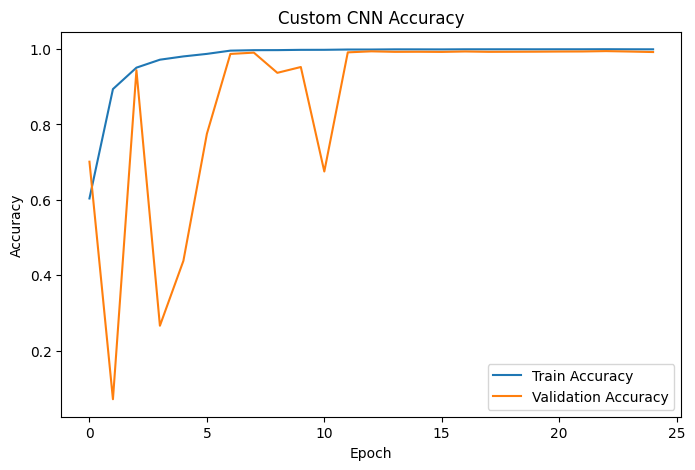

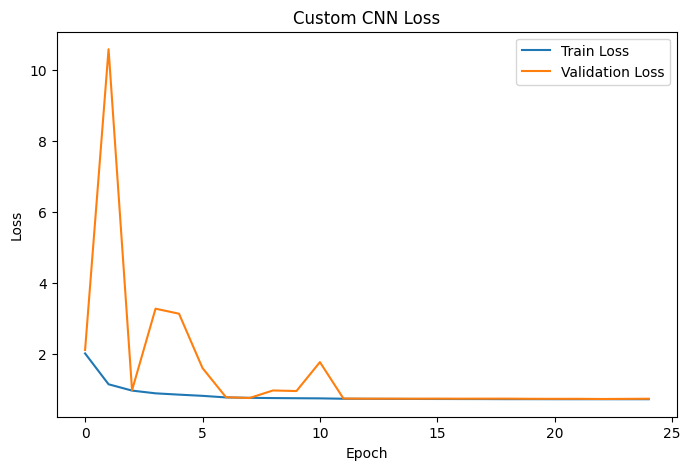

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 19. Evaluate Custom CNN

In [20]:
best_cnn_model = tf.keras.models.load_model(cnn_checkpoint_path)

cnn_test_loss, cnn_test_acc = best_cnn_model.evaluate(test_ds)

print("Custom CNN Test Loss:", cnn_test_loss)
print("Custom CNN Test Accuracy:", cnn_test_acc)

163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9958 - loss: 0.7371
Custom CNN Test Loss: 0.7371320128440857
Custom CNN Test Accuracy: 0.9957740902900696


# Part B: EfficientNetB0 Transfer Learning

Transfer learning is usually better for small or medium image datasets.

EfficientNetB0 already learned many visual features from ImageNet, so we fine-tune it for logo classification.

## 20. Build EfficientNetB0 Model

In [21]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.40)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.40)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

efficientnet_model = models.Model(inputs, outputs)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logo_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,393,931 (16.76 MB)

 Trainable params: 341,288 (1.30 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

## 21. Train EfficientNetB0 Head

In [22]:
efficientnet_checkpoint_path = "/kaggle/working/best_laliga_logo_efficientnet.keras"

efficientnet_callbacks = [
    ModelCheckpoint(
        efficientnet_checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

efficientnet_history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=efficientnet_callbacks
)

Epoch 1/30


E0000 00:00:1780204254.641180      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_6_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8192 - loss: 0.7306
Epoch 1: val_accuracy improved from None to 0.99557, saving model to /kaggle/working/best_laliga_logo_efficientnet.keras

Epoch 1: finished saving model to /kaggle/working/best_laliga_logo_efficientnet.keras
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 133s 93ms/step - accuracy: 0.9263 - loss: 0.2939 - val_accuracy: 0.9956 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 2/30
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9792 - loss: 0.0725
Epoch 2: val_accuracy improved from 0.99557 to 0.99769, saving model to /kaggle/working/best_laliga_logo_efficientnet.keras

Epoch 2: finished saving model to /kaggle/working/best_laliga_logo_efficientnet.keras
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 117s 90ms/step - accuracy: 0.9802 - loss: 0.0686 - val_accuracy: 0.9977 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 3/30
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9839 - loss: 0.0523
Epoch 3: val_accuracy improved fr

## 22. Fine-Tune EfficientNetB0

In [23]:
best_efficientnet_model = tf.keras.models.load_model(efficientnet_checkpoint_path)

# Get EfficientNet base model by name
base_model_inside = None

for layer in best_efficientnet_model.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        base_model_inside = layer
        break

if base_model_inside is None:
    raise ValueError("Could not find EfficientNet base model inside the saved model.")

base_model_inside.trainable = True

# Freeze most layers and train only the last layers
for layer in base_model_inside.layers[:-30]:
    layer.trainable = False

best_efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = best_efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=efficientnet_callbacks
)

Epoch 1/15


E0000 00:00:1780207773.696054      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_6_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9612 - loss: 0.1318
Epoch 1: val_accuracy did not improve from 1.00000
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 155s 108ms/step - accuracy: 0.9678 - loss: 0.1092 - val_accuracy: 0.9979 - val_loss: 0.0059 - learning_rate: 1.0000e-05
Epoch 2/15
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9789 - loss: 0.0666
Epoch 2: val_accuracy did not improve from 1.00000
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 136s 105ms/step - accuracy: 0.9818 - loss: 0.0585 - val_accuracy: 0.9987 - val_loss: 0.0033 - learning_rate: 1.0000e-05
Epoch 3/15
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9877 - loss: 0.0386
Epoch 3: val_accuracy did not improve from 1.00000

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 136s 104ms/step - accuracy: 0.9877 - loss: 0.0388 - val_accuracy: 0.9990 - val_loss: 0.0025 - learning_rate: 1.0000e-05
Epoch 4/15
1300/1300 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - acc

## 23. Plot EfficientNet Results

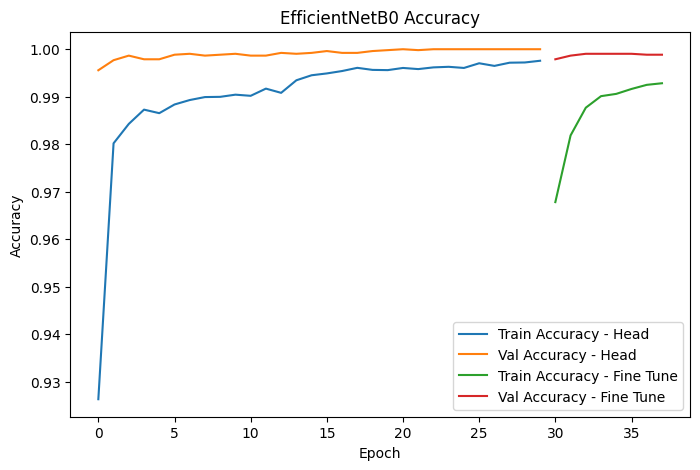

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(efficientnet_history.history["accuracy"], label="Train Accuracy - Head")
plt.plot(efficientnet_history.history["val_accuracy"], label="Val Accuracy - Head")

if "fine_tune_history" in globals():
    offset = len(efficientnet_history.history["accuracy"])
    plt.plot(
        range(offset, offset + len(fine_tune_history.history["accuracy"])),
        fine_tune_history.history["accuracy"],
        label="Train Accuracy - Fine Tune"
    )
    plt.plot(
        range(offset, offset + len(fine_tune_history.history["val_accuracy"])),
        fine_tune_history.history["val_accuracy"],
        label="Val Accuracy - Fine Tune"
    )

plt.title("EfficientNetB0 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 24. Final EfficientNet Evaluation

In [25]:
final_model = tf.keras.models.load_model(efficientnet_checkpoint_path)

final_test_loss, final_test_acc = final_model.evaluate(test_ds)

print("EfficientNet Final Test Loss:", final_test_loss)
print("EfficientNet Final Test Accuracy:", final_test_acc)

163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.9998 - loss: 0.0016   
EfficientNet Final Test Loss: 0.001613160828128457
EfficientNet Final Test Accuracy: 0.9998078942298889


# Model Evaluation

## 25. Classification Report

In [26]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = final_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                              precision    recall  f1-score   support

                    Albacete       1.00      1.00      1.00       130
                     Almeria       1.00      1.00      1.00       131
                     Andorra       1.00      1.00      1.00       130
             Athletic Bilbao       1.00      1.00      1.00       130
             Atletico Madrid       1.00      1.00      1.00       130
                   Barcelona       1.00      1.00      1.00       130
                      Burgos       1.00      1.00      1.00       131
                       Cadiz       1.00      1.00      1.00       130
                   Castellon       1.00      1.00      1.00       131
                  Celta Vigo       1.00      1.00      1.00       130
                       Ceuta       1.00      1.00      1.00       130
Cultural y Deportiva Leonesa       1.00      1.00      1.00       130
            Deportivo Alaves       1.00      1.00      1.00       130
      Deportivo de 

## 26. Confusion Matrix

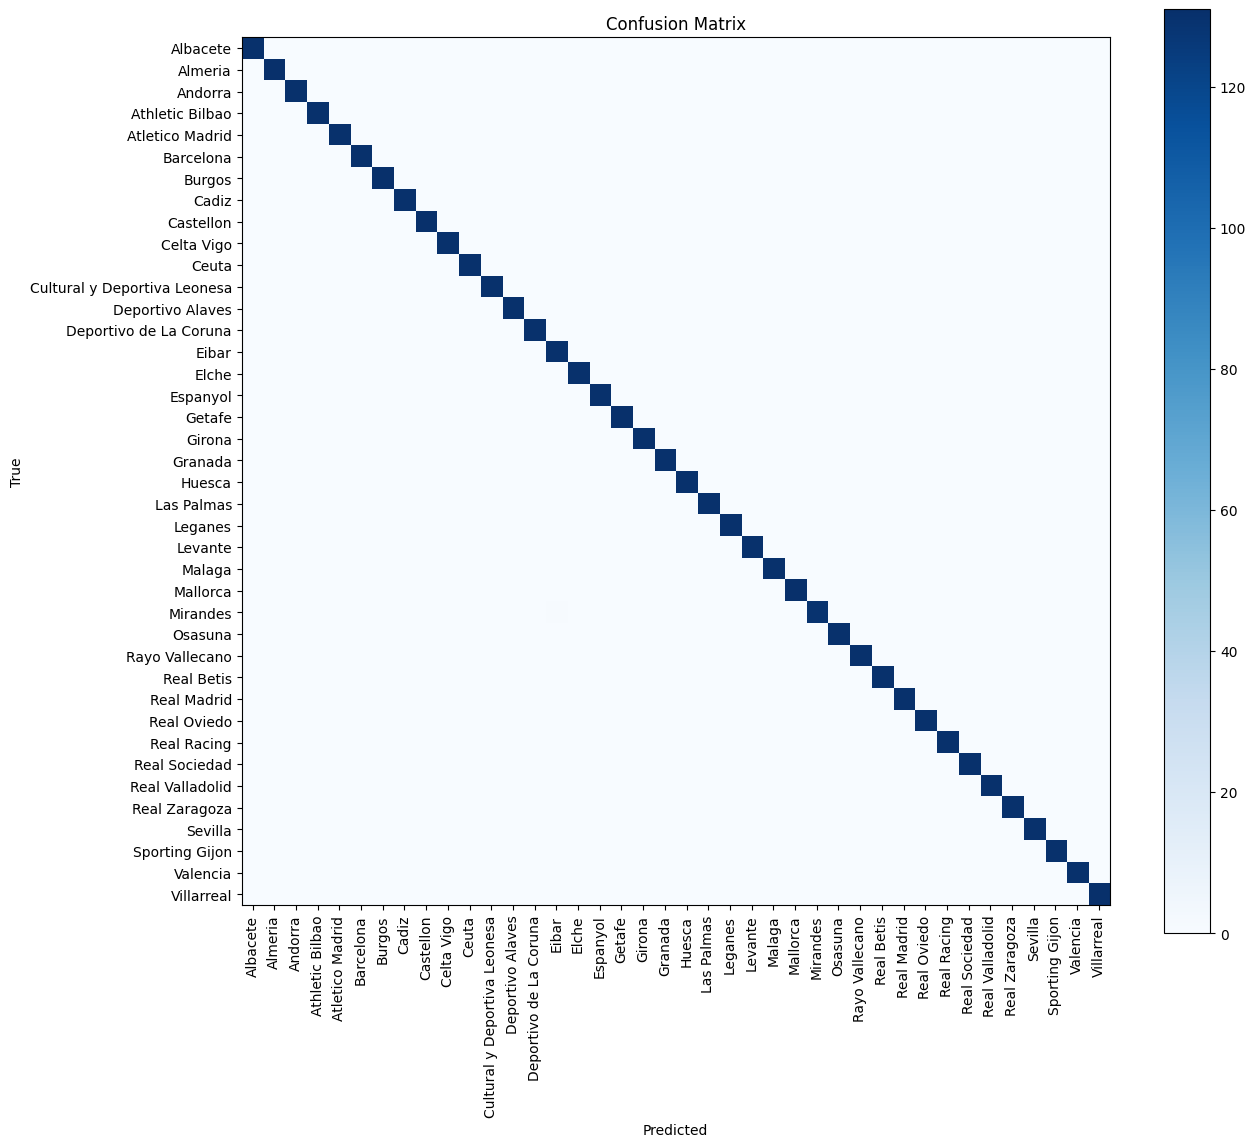

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(num_classes), class_names, rotation=90)
plt.yticks(np.arange(num_classes), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

## 27. Save Class Names

In [28]:
class_names_path = "/kaggle/working/class_names.json"

with open(class_names_path, "w") as f:
    json.dump(class_names, f)

print("Saved class names to:", class_names_path)

Saved class names to: /kaggle/working/class_names.json


## 28. Single Image Prediction Function

In [29]:
def predict_logo(image_path, model_path=efficientnet_checkpoint_path, class_names_path=class_names_path):
    model = tf.keras.models.load_model(model_path)

    with open(class_names_path, "r") as f:
        loaded_class_names = json.load(f)

    processed = remove_logo_background(image_path, output_size=IMG_SIZE)

    if processed is None:
        raise ValueError("Could not read or preprocess the image.")

    img_array = np.expand_dims(processed, axis=0)

    preds = model.predict(img_array, verbose=0)

    pred_idx = int(np.argmax(preds))
    confidence = float(np.max(preds))

    predicted_class = loaded_class_names[pred_idx]

    plt.figure(figsize=(4, 4))
    plt.imshow(processed)
    plt.axis("off")
    plt.title(f"{predicted_class} - {confidence:.2%}")
    plt.show()

    return predicted_class, confidence

## 29. Test Single Prediction

In [30]:
sample_path = sample_images[0]

predicted_class, confidence = predict_logo(sample_path)

print("Predicted:", predicted_class)
print("Confidence:", confidence)

NameError: name 'remove_logo_background' is not defined

# Final Notes

Recommended model:

```text
EfficientNetB0 + logo background removal + light augmentation
```

Recommended deployment files:

1. `/kaggle/working/best_laliga_logo_efficientnet.keras`
2. `/kaggle/working/class_names.json`

If the background removal preview looks bad for some classes, try training two versions:

1. Original images only.
2. Preprocessed images.

Then compare test accuracy and confusion matrix.